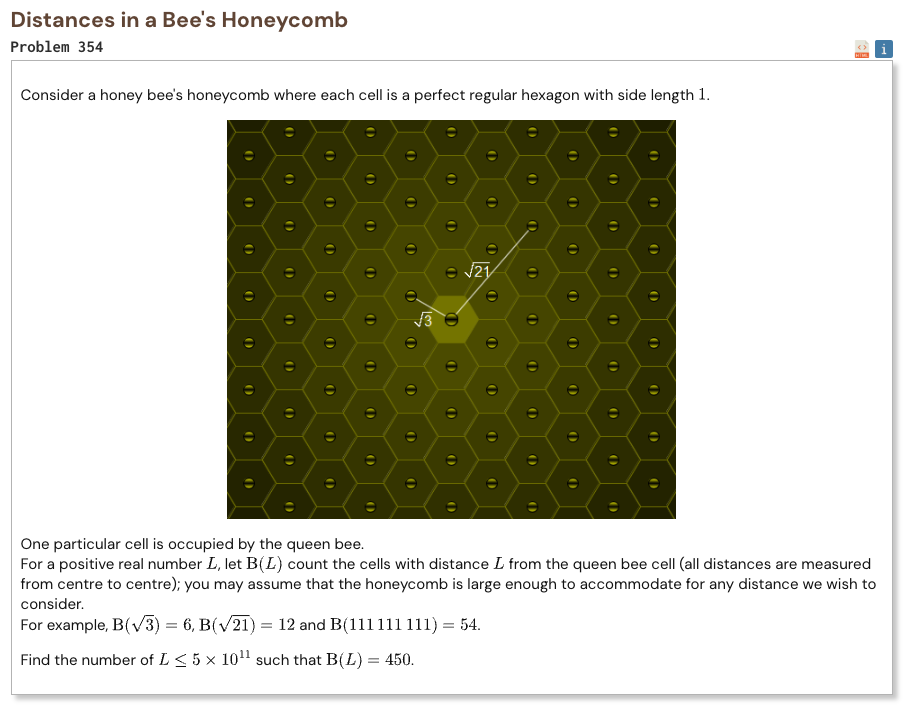

## Initial approach

* model honeycomb centres as points on a triangular lattice
* squared distances are controlled by the norm x*x + x*y + y*y
* the number of cells at a distance comes from prime factors modulo 3
* we need the representation count to be exactly 450
* divide by the basic symmetry factor 6, so the prime-exponent product must be 75
* enumerate only the possible exponent patterns for primes equal to 1 modulo 3
* multiply by allowed powers of 3 and squares of primes equal to 2 modulo 3

In [1]:
import math
import itertools

def sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            is_prime[p * p:limit + 1:p] = b"\x00" * (((limit - p * p) // p) + 1)

    return is_prime

def spf_sieve(limit):
    spf = list(range(limit + 1))

    for p in range(2, math.isqrt(limit) + 1):
        if spf[p] == p:
            for multiple in range(p * p, limit + 1, p):
                if spf[multiple] == multiple:
                    spf[multiple] = p

    return spf

def factor_partitions(n, minimum=2):
    if n == 1:
        yield []
        return

    for factor in range(minimum, n + 1):
        if n % factor == 0:
            for rest in factor_partitions(n // factor, factor):
                yield [factor] + rest

def count_inert_square_multipliers(limit, prefix):
    total = 0
    power3 = 1

    while power3 <= limit:
        total += prefix[math.isqrt(limit // power3)]
        power3 *= 3

    return total

def solve(limit):
    norm_limit = limit // 3
    root_limit = math.isqrt(norm_limit)

    is_prime = sieve(root_limit)
    split_primes = [p for p in range(2, root_limit + 1) if is_prime[p] and p % 3 == 1]

    patterns = set()

    for parts in factor_partitions(75):
        patterns.add(tuple(part - 1 for part in parts))

    bases = set()

    for pattern in patterns:
        for exponents in set(itertools.permutations(pattern)):
            def dfs(index, start, value):
                if index == len(exponents):
                    bases.add(value)
                    return

                exponent = exponents[index]

                for prime_index in range(start, len(split_primes)):
                    prime = split_primes[prime_index]
                    next_value = value * prime ** exponent

                    if next_value > norm_limit:
                        break

                    dfs(index + 1, prime_index + 1, next_value)

            dfs(0, 0, 1)

    spf = spf_sieve(root_limit)
    inert_only = [False] * (root_limit + 1)
    inert_only[1] = True

    for n in range(2, root_limit + 1):
        p = spf[n]
        inert_only[n] = inert_only[n // p] and p % 3 == 2

    prefix = [0] * (root_limit + 1)
    count = 0

    for n in range(1, root_limit + 1):
        if inert_only[n]:
            count += 1

        prefix[n] = count

    result = 0

    for base in bases:
        result += count_inert_square_multipliers(norm_limit // base, prefix)

    return result

In [2]:
%%time
result = solve(5 * 10 ** 11)
print("Result:", result)

Result: 8
CPU times: user 85.3 ms, sys: 2.36 ms, total: 87.6 ms
Wall time: 87 ms
